In [2]:
import json

kaggle_dict = {
    "username": "Sathya Mozhi",
    "key": "KGAT_ce2016f704f725fd31c0c84a8c8eb048"
}

with open("kaggle.json", "w") as file:
    json.dump(kaggle_dict, file)

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d sobhanmoosavi/us-accidents
!unzip us-accidents.zip

Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
 98% 639M/653M [00:03<00:00, 49.0MB/s]
100% 653M/653M [00:03<00:00, 182MB/s] 
Archive:  us-accidents.zip
  inflating: US_Accidents_March23.csv  


In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [6]:
columns_needed = ['Severity', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)']

df = pd.read_csv(
    "US_Accidents_March23.csv",
    usecols=columns_needed,
    nrows=100000   # load only 100k rows to avoid crash
)

df = df.dropna()

df.head()

,Severity,Temperature(F),Humidity(%),Pressure(in)
0,3,36.9,91.0,29.68
1,2,37.9,100.0,29.65
2,2,36.0,100.0,29.67
3,3,35.1,96.0,29.64
4,2,36.0,89.0,29.65


In [7]:
X = df[['Temperature(F)', 'Humidity(%)', 'Pressure(in)']]
y = df['Severity']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
model = SVC()

model.fit(X_train, y_train)

SVC()

In [11]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5587394500408386


In [12]:
# New weather input
new_data = pd.DataFrame({
    'Temperature(F)': [75],
    'Humidity(%)': [60],
    'Pressure(in)': [29.8]
})

# Scale the new input (IMPORTANT!)
new_data_scaled = scaler.transform(new_data)

# Predict severity
prediction = model.predict(new_data_scaled)

print("Predicted Accident Severity:", prediction[0])


Predicted Accident Severity: 2


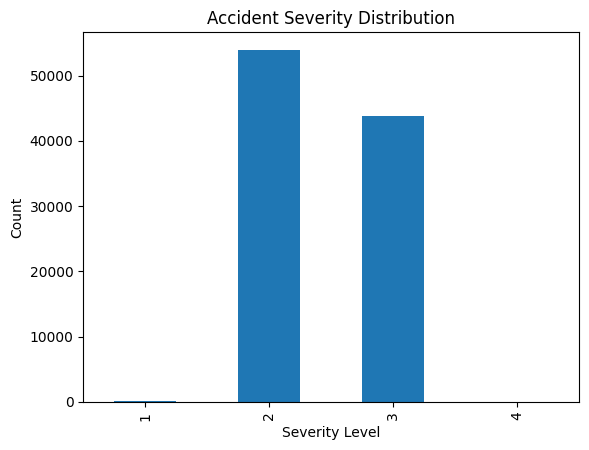

In [13]:
import matplotlib.pyplot as plt

# Class distribution
df['Severity'].value_counts().sort_index().plot(kind='bar')
plt.title("Accident Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Count")
plt.show()

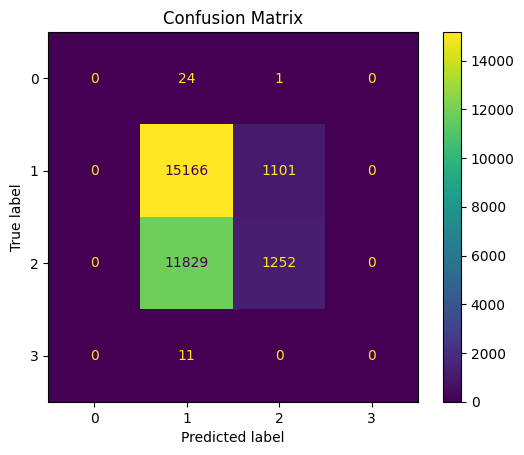

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

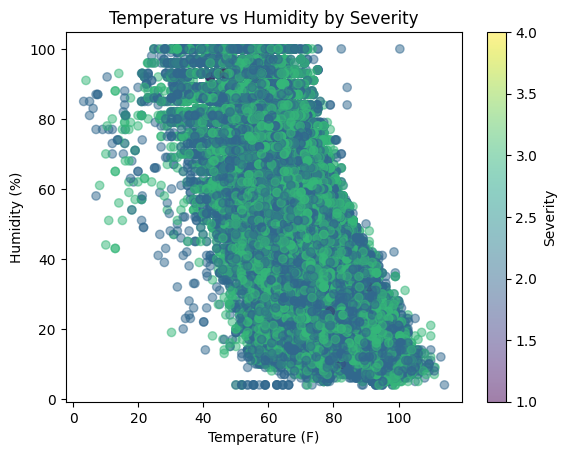

In [15]:
plt.scatter(df['Temperature(F)'], df['Humidity(%)'],
            c=df['Severity'], cmap='viridis', alpha=0.5)

plt.xlabel("Temperature (F)")
plt.ylabel("Humidity (%)")
plt.title("Temperature vs Humidity by Severity")
plt.colorbar(label="Severity")
plt.show()

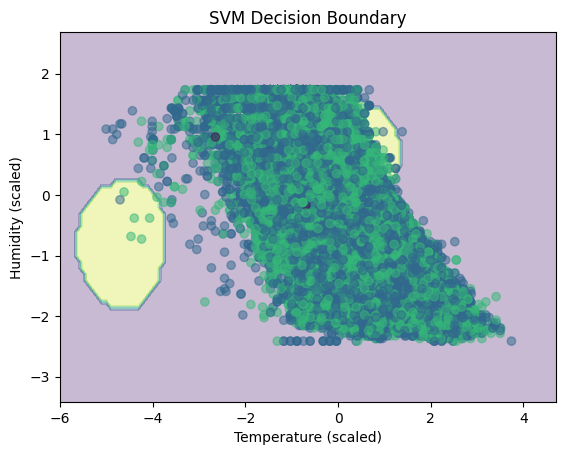

In [16]:
import numpy as np

# Take only two features
X2 = df[['Temperature(F)', 'Humidity(%)']]
y2 = df['Severity']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.3, random_state=42)

scaler2 = StandardScaler()
X_train2 = scaler2.fit_transform(X_train2)

model2 = SVC()
model2.fit(X_train2, y_train2)

# Create mesh grid
x_min, x_max = X_train2[:, 0].min() - 1, X_train2[:, 0].max() + 1
y_min, y_max = X_train2[:, 1].min() - 1, X_train2[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = model2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train2[:, 0], X_train2[:, 1], c=y_train2, alpha=0.5)
plt.title("SVM Decision Boundary")
plt.xlabel("Temperature (scaled)")
plt.ylabel("Humidity (scaled)")
plt.show()